# 05 - NCF Model (Neural Collaborative Filtering)


## Step 1: Setup

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

FEATURE_DIR = "../data/features"

Using device: mps


## Step 2: Load the Train/Test Data
This is the output of `04_feature_engineering.ipynb` — (user, restaurant, label) rows.

In [14]:
df_train = pd.read_csv(f"{FEATURE_DIR}/train_interactions.csv")
df_test = pd.read_csv(f"{FEATURE_DIR}/test_interactions.csv")

user_id_map = pd.read_csv(f"{FEATURE_DIR}/user_id_map.csv", index_col=0)
item_id_map = pd.read_csv(f"{FEATURE_DIR}/item_id_map.csv", index_col=0)

N_USERS = len(user_id_map)
N_ITEMS = len(item_id_map)

print("Train rows:", df_train.shape[0])
print("Test rows:", df_test.shape[0])
print("N_USERS:", N_USERS, "| N_ITEMS:", N_ITEMS)

Train rows: 22560
Test rows: 486300
N_USERS: 56331 | N_ITEMS: 596


## Step 3: Build a PyTorch Dataset
A `Dataset` just tells PyTorch how to fetch one row at a time (user index, item index, label). The `DataLoader` then handles batching and shuffling for us during training.

In [15]:
class InteractionDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df["user_idx"].values, dtype=torch.long)
        self.items = torch.tensor(df["item_idx"].values, dtype=torch.long)
        self.labels = torch.tensor(df["label"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]

train_dataset = InteractionDataset(df_train)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

print("Number of training batches:", len(train_loader))

Number of training batches: 89


## Step 4: Define the NCF Model
Two embedding tables (one for users, one for restaurants) feed into a small MLP (multi-layer perceptron). The final layer squashes the output into a 0-1 probability with a sigmoid.

In [16]:
class NCF(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim=32):
        super().__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, user_idx, item_idx):
        user_vec = self.user_embedding(user_idx)
        item_vec = self.item_embedding(item_idx)
        x = torch.cat([user_vec, item_vec], dim=1)   # glue the two vectors together
        logit = self.mlp(x)
        return torch.sigmoid(logit).squeeze()          # squash to a 0-1 probability

EMBEDDING_DIM = 16   # smaller than before (was 32) — with sparse data, fewer parameters means
                       # less for the model to learn from limited examples, reducing the risk
                       # that embeddings stay close to their random starting point

model = NCF(N_USERS, N_ITEMS, embedding_dim=EMBEDDING_DIM).to(device)
print(model)

NCF(
  (user_embedding): Embedding(56331, 16)
  (item_embedding): Embedding(596, 16)
  (mlp): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Step 5: Set Up Loss Function and Optimizer
- **Loss function (BCELoss):** measures how wrong the predicted probability was compared to the real 0/1 label.
- **Optimizer (Adam):** adjusts the model's weights to reduce that loss over time.
- **Weight decay:** a regularization term added to the optimizer. It gently discourages embeddings from growing very large, which helps prevent overfitting to the few interactions each user has.

In [17]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

## Step 6: Training Loop
For each epoch (one full pass through the training data), we:
1. Get a batch of (user, item, label) rows
2. Ask the model to predict a probability
3. Compare it to the real label and compute the loss
4. Update the model's weights to reduce that loss

We repeat this for several epochs, and the loss should go down over time. We increased epochs from 10 to 30, since the earlier run likely stopped before the embeddings had enough passes over the (small) dataset to move meaningfully away from their random starting values.

In [18]:
N_EPOCHS = 50

model.train()
loss_history = []

for epoch in range(N_EPOCHS):
    total_loss = 0
    for users, items, labels in train_loader:
        users, items, labels = users.to(device), items.to(device), labels.to(device)

        optimizer.zero_grad()
        predictions = model(users, items)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{N_EPOCHS} - avg loss: {avg_loss:.4f}")

Epoch 1/50 - avg loss: 0.6279
Epoch 5/50 - avg loss: 0.4821
Epoch 10/50 - avg loss: 0.4208
Epoch 15/50 - avg loss: 0.3696
Epoch 20/50 - avg loss: 0.2932
Epoch 25/50 - avg loss: 0.2097
Epoch 30/50 - avg loss: 0.1361
Epoch 35/50 - avg loss: 0.0846
Epoch 40/50 - avg loss: 0.0478
Epoch 45/50 - avg loss: 0.0262
Epoch 50/50 - avg loss: 0.0140


## Step 6b: Plot the Training Curve

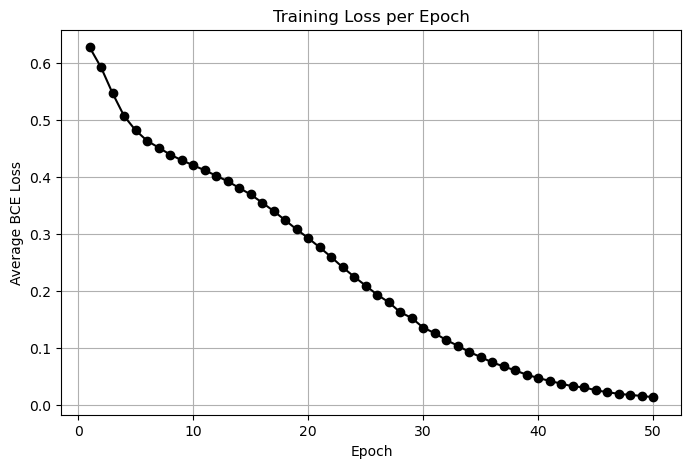

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, N_EPOCHS + 1), loss_history, marker="o", color='black')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Average BCE Loss")
plt.grid(True)
plt.show()

## Step 7: Evaluation Metrics — Hit Rate@K and NDCG@K
For each test user we have 1 restaurant they actually liked (label=1) mixed in with 99 restaurants they didn't interact with. We ask the model to score all 100 and rank them.

- **Hit Rate@K:** did the liked restaurant appear anywhere in the model's top-K ranked list? (1 = yes, 0 = no)
- **NDCG@K:** like Hit Rate, but gives more credit if the liked restaurant is ranked closer to #1, not just anywhere in the top-K.

In [20]:
def evaluate_model(model, df_test, k=10):
    model.eval()
    hits = []
    ndcgs = []

    with torch.no_grad():
        for user_idx, group in df_test.groupby("user_idx"):
            users = torch.tensor([user_idx] * len(group), dtype=torch.long).to(device)
            items = torch.tensor(group["item_idx"].values, dtype=torch.long).to(device)
            labels = group["label"].values

            scores = model(users, items).cpu().numpy()

            # Rank items by predicted score, highest first
            ranked_indices = np.argsort(-scores)
            ranked_labels = labels[ranked_indices]

            top_k_labels = ranked_labels[:k]

            # Hit Rate: was the liked item (label=1) anywhere in the top k?
            hit = 1 if 1 in top_k_labels else 0
            hits.append(hit)

            # NDCG: extra credit for ranking it near the top
            if hit:
                rank_position = np.where(top_k_labels == 1)[0][0]
                ndcg = 1 / np.log2(rank_position + 2)   # +2 because rank_position starts at 0
            else:
                ndcg = 0
            ndcgs.append(ndcg)

    return np.mean(hits), np.mean(ndcgs)

hit_rate, ndcg = evaluate_model(model, df_test, k=10)
print(f"NCF Model  -> Hit Rate@10: {hit_rate:.4f} | NDCG@10: {ndcg:.4f}")

NCF Model  -> Hit Rate@10: 0.4271 | NDCG@10: 0.2458


## Step 8: Popularity Baseline (for comparison)


In [21]:
# Count how often each restaurant appears as a positive interaction in training data
popularity_scores = df_train[df_train["label"] == 1]["item_idx"].value_counts()

def evaluate_popularity_baseline(df_test, popularity_scores, k=10):
    hits = []
    ndcgs = []

    for user_idx, group in df_test.groupby("user_idx"):
        items = group["item_idx"].values
        labels = group["label"].values

        # Score = popularity count (0 if the restaurant was never seen in training)
        scores = np.array([popularity_scores.get(i, 0) for i in items])

        ranked_indices = np.argsort(-scores)
        ranked_labels = labels[ranked_indices]
        top_k_labels = ranked_labels[:k]

        hit = 1 if 1 in top_k_labels else 0
        hits.append(hit)

        if hit:
            rank_position = np.where(top_k_labels == 1)[0][0]
            ndcg = 1 / np.log2(rank_position + 2)
        else:
            ndcg = 0
        ndcgs.append(ndcg)

    return np.mean(hits), np.mean(ndcgs)

pop_hit_rate, pop_ndcg = evaluate_popularity_baseline(df_test, popularity_scores, k=10)
print(f"Popularity Baseline -> Hit Rate@10: {pop_hit_rate:.4f} | NDCG@10: {pop_ndcg:.4f}")

Popularity Baseline -> Hit Rate@10: 0.5293 | NDCG@10: 0.3302


## Step 9: Compare Results

In [22]:
results = pd.DataFrame({
    "Model": ["Popularity Baseline", "Neural Collaborative Filtering"],
    "Hit Rate@10": [pop_hit_rate, hit_rate],
    "NDCG@10": [pop_ndcg, ndcg]
})
results

,Model,Hit Rate@10,NDCG@10
0,Popularity Baseline,0.529303,0.330189
1,Neural Collaborative Filtering,0.427103,0.245820


## Step 10: Save the Trained Model


In [23]:
import os
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

torch.save(model.state_dict(), f"{MODEL_DIR}/ncf_model.pt")
print("Model saved to:", f"{MODEL_DIR}/ncf_model.pt")

Model saved to: models/ncf_model.pt
